### Preparation

In [1]:
import anndata
import scanpy as sc
import torch
from scipy import stats
import statsmodels
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from matplotlib_venn import venn2
from collections import defaultdict

from tqdm import tqdm

from cellwhisperer.config import get_path
from cellwhisperer.jointemb.dataset.inference import CellxGenePreparationLoader

import pickle as pkl

import matplotlib
matplotlib.style.use(get_path(["plot_style"]))

import gseapy as gp

sc.set_figure_params(vector_friendly=True, dpi_save=500)

/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cellwhisperer scoring
from cellwhisperer.utils.model_io import load_cellwhisperer_model
from cellwhisperer.utils.inference import score_transcriptomes_vs_texts
from cellwhisperer.config import get_path


/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/wandb/analytics/sentry.py:90: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  self.hub = sentry_sdk.Hub(client)


In [3]:
ckpt_file_path = "./results/models/jointemb/cellwhisperer_clip_v2_uce.ckpt"
(   pl_model_cellwhisperer,
    text_processor_cellwhisperer,
    transcriptome_processor_cellwhisperer,
) = load_cellwhisperer_model(model_path=ckpt_file_path, eval=True)


/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [4]:
texts_list = ["CD4+ T cell", "muscle"]

### Loading the subsample scores

In [5]:
SUBSAMPLE_ARCHS4_DATA_PATH = "./data/archs4_geo/cellxgene_subsampled_01.h5ad"
sub_archs4_adata = anndata.read_h5ad(SUBSAMPLE_ARCHS4_DATA_PATH)

In [6]:
import pickle
import os

filename = "./data/archs4_geo/cellxgene_subsampled_01_scores.pkl"

if os.path.exists(filename) and os.path.getsize(filename) > 0:
    with open(filename, "rb") as f:
        subsample_score = pickle.load(f)
else:
    raise FileNotFoundError(f"The file '{filename}' is either missing or empty.")

In [7]:
# %load_ext autoreload
# %autoreload 2

In [5]:
sub_archs4_adata.layers["counts"] = sub_archs4_adata.X.copy()

### Subsampling the subsample

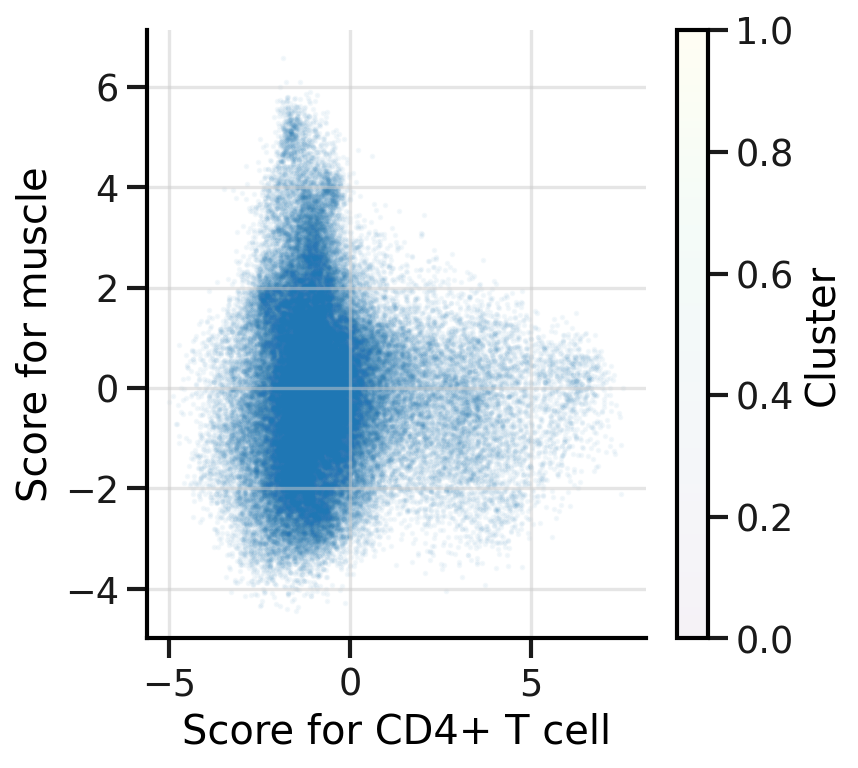

In [6]:
# make a scatterplot with scores
plt.figure(figsize=(5, 5))

# Ensure that the cluster column is converted to a categorical type if it's not already
# adata.obs["cluster"] = adata.obs["leiden"].astype('category')

# Use the cluster codes as colors
plt.scatter(subsample_score[0, :], subsample_score[1, :], s=1, alpha=0.05)  # , c=adata.obs["cluster"].cat.codes, cmap='viridis')
plt.xlabel(f"Score for {texts_list[0]}")
plt.ylabel(f"Score for {texts_list[1]}")
plt.colorbar(label='Cluster')
plt.show()

In [9]:
sub_archs4_adata.obsm["transcriptome_embeds"].shape

(70543, 2048)

In [7]:
# get cell idxs with cd4+ T cell score with a score over 7 (arbitrary threshold)
cd4_cell_idx = np.where(subsample_score[0, :] > 3.5)[0]
print("number of selected CD4+ T cells:{}".format(len(cd4_cell_idx)) )

# get cells idxs with muscle index with a score over 7 (arbitrary threshold)
muscle_cell_idx = np.where(subsample_score[1, :] > 3.5)[0]
print("number of selected muscle cells:{}".format(len(muscle_cell_idx)) )


# get random 1000 cells from the dataset
np.random.seed(42)
random_idx = np.random.choice(sub_archs4_adata.obsm["transcriptome_embeds"].shape[0], 1000, replace=False)

# combine cd4 and muscle cell and random cell idxs
selected_cells_idx = np.concatenate([cd4_cell_idx, muscle_cell_idx, random_idx])
print("number of selected cells:{}".format(len(selected_cells_idx)) )

number of selected CD4+ T cells:2642
number of selected muscle cells:2145
number of selected cells:5787


In [8]:
adata_subset = sub_archs4_adata[selected_cells_idx, :]
scores_subset = subsample_score[:, selected_cells_idx]

### Creating the dataloader

In [9]:
def ensure_raw_counts_adata(adata):
    # Check if the values in the X layer are counts (i.e., integers)
    comp = np.abs(adata.X[:100] - adata.X[:100].astype(int))
    if isinstance(adata.X, sparse.csr_matrix):
        comp = comp.toarray()

    if not np.all(comp < 1e-6):
        try:
            adata.X = adata.layers["counts"]
        except KeyError:
            raise ValueError(
                'adata.X contains normalized counts, but raw counts are not provided in adata.layers["counts"].'
            )


In [10]:
from pathlib import Path
from typing import Union
from torch.utils.data import DataLoader
from cellwhisperer.jointemb.processing import TranscriptomeTextDualEncoderProcessor
from cellwhisperer.jointemb.dataset.jointemb import JointEmbedDataset
class CellxGenePreparationLoader(DataLoader):
    """
    Prepare the dataset.

    Only prepare the transcriptome data
    """

    def __init__(
        self,
        read_count_table: Union[anndata.AnnData, Path, str],
        transcriptome_processor="geneformer",
        transcriptome_processor_kwargs={},
        **kwargs
    ):
        """ """
        if isinstance(read_count_table, (str, Path)):
            read_count_table = anndata.read_h5ad(read_count_table)

        # ensure_raw_counts_adata(read_count_table)

        self.transcriptome_processor = transcriptome_processor
        self.transcriptome_processor_kwargs = transcriptome_processor_kwargs

        # Load data and processor
        processor = TranscriptomeTextDualEncoderProcessor(
            self.transcriptome_processor,
            "dmis-lab/biobert-v1.1",  # unused
        )

        inputs = processor(
            text=None,
            transcriptomes=read_count_table,
            return_tensors="pt",
            padding="max_length",  # not sure if required (shouldn't actually)
        )

        dataset = JointEmbedDataset(
            inputs,
            orig_ids=read_count_table.obs.index.to_numpy(),
        )
        super().__init__(dataset, **kwargs)


### Captum

In [11]:
uce_model = pl_model_cellwhisperer.model.transcriptome_model.model
pl_model_cellwhisperer.model.transcriptome_model = pl_model_cellwhisperer.model.transcriptome_model.model.eval().to(
    pl_model_cellwhisperer.model.device
) # TODO transcriptome model shouldn't be frozen actually..

In [12]:
import captum

In [17]:
# _, cls = uce_model.forward(**transcriptome_batch)
# cls
# cls.shape
# del cls

In [14]:
query_batch = text_processor_cellwhisperer(["CD4+ T cell"])
query_batch 

{'input_ids': [[101, 2891, 1527, 116, 157, 2765, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1]]}

In [15]:
query_features, query_embeds = pl_model_cellwhisperer.model.get_text_features(**{k: torch.tensor(t).to(pl_model_cellwhisperer.model.device) for k,t in query_batch.items()}, normalize_embeds=True)
query_embeds = query_embeds.detach() # treat query as constant value to 'optimize against'
query_embeds.shape

torch.Size([1, 2048])

In [23]:
query_features.shape

torch.Size([1, 768])

In [ ]:
pl_model_cellwhisperer.model.device

device(type='cuda', index=0)

In [16]:
import torch.nn as nn
# TODO Might be implemented directly via my `model.py` (just reuse the `forward` function?). That way we also stay flexible with query_embeds
class IntegrationModule(nn.Module):
    def __init__(self, pl_model_cellwhisperer, query_embeds):  
        super(IntegrationModule, self).__init__()
        self.model = pl_model_cellwhisperer.model
        self.query_embeds = query_embeds

    def forward(self, expression_expr, expression_key_padding_mask):
        transcriptome_embeds = self.model.get_transcriptome_features(
            expression_expr=expression_expr,
            expression_key_padding_mask=expression_key_padding_mask,
            normalize_embeds=True
        )[1]
        
        res = torch.einsum("nd,md->nm", [self.query_embeds, transcriptome_embeds]) * \
              self.model.discriminator.temperature.exp().detach()
        return res[0]

In [17]:
integrator = IntegrationModule(pl_model_cellwhisperer, query_embeds)
# integrator(transcriptome_batch["expression_expr"], transcriptome_batch["expression_key_padding_mask"])

### Code to return from transcriptome embeddings to genes

In [18]:
get_path(["uce_paths", "tmp_feature_path"])

PosixPath('/nobackup/lab_cresswell/ahakobyan/cellwhisperer_private/results/UCE')

In [19]:
ls -lht /nobackup/lab_cresswell/ahakobyan/cellwhisperer_private/results/UCE | head  

total 341G
-rw-rw---- 1 ahakobyan lab_cresswell 6.6M Mar 24 18:47 enr_results.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 1.4M Mar 24 18:36 top_genes_list.torch
-rw-rw---- 1 ahakobyan lab_cresswell  51M Mar 24 18:35 all_res_IG.torch
-rw-rw---- 1 ahakobyan lab_cresswell  52M Mar 24 18:35 all_res_list.torch
-rw-rw---- 1 ahakobyan lab_cresswell 299K Mar 24 17:59 aba5f1df507a4fb68c35696df47e1ea8_chroms.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 156K Mar 24 17:59 aba5f1df507a4fb68c35696df47e1ea8_pe_idx.torch
-rw-rw---- 1 ahakobyan lab_cresswell 155K Mar 24 17:59 aba5f1df507a4fb68c35696df47e1ea8_starts.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 871M Mar 24 17:59 aba5f1df507a4fb68c35696df47e1ea8_counts.npz
-rw-rw---- 1 ahakobyan lab_cresswell 871M Mar 24 17:58 82dc1746d2cb457996ce2db3f9759786_counts.npz


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
from UCE.data_proc.data_utils import (
    get_species_to_pe,
    anndata_to_sc_dataset,
    data_to_torch_X,
    get_spec_chrom_csv,
    adata_path_to_prot_chrom_starts,
)

In [ ]:
# pad_length=1152
# sample_size = 1024

# TOKEN_DIM = 5120
# PE_DIM = 1280  # ESM2 embedding dimension

# cls_token_idx = 3
# chrom_token_offset = 143574
# chrom_token_right_idx = 2
# pad_token_idx = 0

### Going from embeds to genes

In [ ]:
# Suppress scientific notation for tensor printing
torch.set_printoptions(sci_mode=False)

# Print the tensor
print(transcriptome_batch["expression_expr"])

tensor([[        3.,    144147.,     27060.,  ...,         0.,         0.,
                 0.],
        [        3.,    144144.,     30415.,  ...,         0.,         0.,
                 0.]], device='cuda:0')


In [ ]:
pe_idx

tensor([31510, 30934, 18004,  ..., 27868, 26382, 18798])

In [ ]:
# create a set from the elements of res_out_test without a tensor
res_out_test_set = set(res_out_test.tolist())

# compare res_out_test_set set to a set from range 0 to 1152
res_out_test_set == set(range(1152))

True

In [ ]:
transcriptome_batch["expression_expr"][0]

tensor([        3.,    144147.,     27060.,  ...,         0.,         0.,
                0.], device='cuda:0')

In [ ]:
pe_idx.to('cpu')
pe_idx

tensor([31510, 30934, 18004,  ..., 27868, 26382, 18798])

### Attributing importance to all cells

In [27]:
dl = CellxGenePreparationLoader(
    read_count_table=adata_subset,
    transcriptome_processor=pl_model_cellwhisperer.model.transcriptome_model.config.model_type,
    batch_size=1,  # low for testing
)

/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/anndata/_core/anndata.py:1898: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


19706
Max Code: 613


/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [21]:
# clean up cuda memory
torch.cuda.empty_cache()

In [22]:
torch.cuda.ipc_collect()

In [35]:
from tqdm import tqdm


In [36]:
device = pl_model_cellwhisperer.model.device
all_res_list = []

for batch_idx, transcriptome_batch in enumerate(tqdm(dl, desc="Processing batches")):
    ig = captum.attr.LayerIntegratedGradients(
        integrator, 
        pl_model_cellwhisperer.model.transcriptome_model.uce_model.pe_embedding
    )
    res = ig.attribute(
        inputs=transcriptome_batch["expression_expr"].to(device),
        # baselines=cell_features_baseline,  # TODO 
        additional_forward_args=(transcriptome_batch["expression_key_padding_mask"].to(device).detach(), ),
        internal_batch_size=1,  # already needs >40GB of VRAM
        n_steps=2,  # TODO increase for higher accuracy
    )
    all_res_list.append(res.sum(-1).argsort())

all_res = torch.cat(all_res_list, dim=0)

Processing batches:   0%|          | 0/579 [00:00<?, ?it/s]

/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/captum/attr/_utils/batching.py:45: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 10 equal to the number of examples.
  warnings.warn(
Processing batches: 100%|█████████▉| 578/579 [27:24<00:02,  2.83s/it]/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/captum/attr/_utils/batching.py:45: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 7 equal to the number of examples.
  warnings.warn(
Processing batches: 100%|██████████| 579/579 [27:27<00:00,  2.84s/it]


In [45]:
# Ensure `get_path` returns a valid path string
output_path = os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "all_res_list.torch")
torch.save(all_res_list, output_path)

In [46]:
# save all_res tensor 
torch.save(all_res, os.path.join(get_path(["uce_paths", "tmp_feature_path"]),"all_res_IG.torch") )

### Getting important genes

In [14]:
# read all_res_list 
all_res_list = torch.load(
	os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "all_res_IG_20steps.torch"),
	map_location=torch.device('cpu')
)

In [ ]:
# read all_res_list 
all_res_list = torch.load(
	os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "all_res_list.torch"),
	map_location=torch.device('cpu')
)

In [24]:
# read all_res tensor
all_res = torch.load(
    os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "all_res_IG.torch"),
    map_location=torch.device('cpu')
)

In [25]:
ls -lht /nobackup/lab_cresswell/ahakobyan/cellwhisperer_private/results/UCE | head  

total 342G
-rw-rw---- 1 ahakobyan lab_cresswell 299K Mar 25 10:20 d91de7f49b7e494f8f1c89e0fa36429a_chroms.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 156K Mar 25 10:20 d91de7f49b7e494f8f1c89e0fa36429a_pe_idx.torch
-rw-rw---- 1 ahakobyan lab_cresswell 155K Mar 25 10:20 d91de7f49b7e494f8f1c89e0fa36429a_starts.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 871M Mar 25 10:20 d91de7f49b7e494f8f1c89e0fa36429a_counts.npz
-rw-rw---- 1 ahakobyan lab_cresswell 6.6M Mar 24 18:47 enr_results.pkl
-rw-rw---- 1 ahakobyan lab_cresswell 1.4M Mar 24 18:36 top_genes_list.torch
-rw-rw---- 1 ahakobyan lab_cresswell  51M Mar 24 18:35 all_res_IG.torch
-rw-rw---- 1 ahakobyan lab_cresswell  52M Mar 24 18:35 all_res_list.torch
-rw-rw---- 1 ahakobyan lab_cresswell 299K Mar 24 17:59 aba5f1df507a4fb68c35696df47e1ea8_chroms.pkl


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [15]:
with open("/nobackup/lab_cresswell/ahakobyan/cellwhisperer_private/results/UCE/" + "38b6ef0e9dc74c329eae8810bd7dfa6e_chroms.pkl", "rb") as f:
    chroms = np.load(f, allow_pickle=True)

chroms = chroms['38b6ef0e9dc74c329eae8810bd7dfa6e']
chroms

gene_symbol
TSPAN6      612
TNMD        612
DPM1        576
SCYL3       564
C1ORF112    564
           ... 
H2AC19      564
PPIAL4C     564
RPSAP58     574
PPIAL4D     564
FAM153B     581
Length: 19706, dtype: int16

In [19]:
pe_idx = torch.load("/nobackup/lab_cresswell/ahakobyan/cellwhisperer_private/results/UCE/" + "38b6ef0e9dc74c329eae8810bd7dfa6e_pe_idx.torch")
pe_idx = pe_idx["38b6ef0e9dc74c329eae8810bd7dfa6e"]

In [88]:
pe_idx

tensor([31510, 30934, 18004,  ..., 27868, 26382, 18798])

In [17]:
def get_important_genes(cell_sentences, res_out, pe_idx, chroms, threshold = 30):
    # get the last 30 elements from res_out
    top_word_indices = res_out[-threshold:].tolist()
    # get the cell sentence elements with indices from top_word_indices
    top_words = cell_sentences[top_word_indices]

    # get the indices of elements from pe_idx that are in top_words
    mask = torch.isin(pe_idx, torch.tensor(top_words))
    gene_indeces = torch.nonzero(mask, as_tuple=True)[0]

    # get elements from chroms with indeces gene_indeces
    top_genes = chroms.iloc[gene_indeces.tolist()]

    return top_genes.index

In [26]:
transcriptome_batch["expression_expr"].shape

torch.Size([10, 1152])

In [24]:
all_res_list.shape

torch.Size([5787, 1152])

In [28]:
# apply the function get_important_genes to all_res_list

# a list to store the top genes
top_genes_list = []

for batch_idx, transcriptome_batch in enumerate(tqdm(dl, desc="Getting top genes")):

    for i in range(transcriptome_batch["expression_expr"].shape[0]):
        # print(batch_idx, i)
        top_genes = get_important_genes(
            transcriptome_batch["expression_expr"][i], 
            all_res_list[batch_idx], 
            pe_idx, 
            chroms, 
            threshold = 30
        )
        top_genes_list.append(top_genes)
        # print(top_genes.index)

Getting top genes:   0%|          | 0/5787 [00:00<?, ?it/s]/tmp/ipykernel_38084/3863795983.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.isin(pe_idx, torch.tensor(top_words))
Getting top genes: 100%|██████████| 5787/5787 [00:03<00:00, 1776.23it/s]


In [29]:
# save top_genes_list list as pkl
import pickle as pkl
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "top_genes_list.pkl"), "wb") as f:
    pkl.dump(top_genes_list, f)


In [33]:
# read top_genes_list list
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "top_genes_list.pkl"), "rb") as f:
    top_genes_list = pkl.load(f)

### Doing GSEA analysis in python

In [36]:
# generate 1000 numbers from 0 to length of top_genes_list
np.random.seed(42)
# random_idx = np.random.choice(len(top_genes_list), 100, replace=False)

In [ ]:
from tqdm import tqdm
from joblib import Parallel, delayed

# run enrichr on every element in top_genes_list and save the results in a list
enr_results = []
def run_enrichr(i):
    return gp.enrichr(
        gene_list=list(top_genes_list[i]),
        gene_sets=["GO_Biological_Process_2021"],
        organism="Human",
        outdir=f"test/enr_DEGs_GOBP_{i}",
        cutoff=0.7,
    )

enr_results = Parallel(n_jobs=-1)(
    delayed(run_enrichr)(i) for i in tqdm(range(len(top_genes_list)), desc="Running Enrichr")
)

Running Enrichr:   0%|          | 0/5787 [00:00<?, ?it/s]/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
Running Enrichr:   0%|          | 1/5787 [00:02<4:14:37,  2.64s/it]/nobackup/lab_cresswell/ahakobyan/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
Running Enrichr:   0%|          | 2/5787 [

ValueError: Warning: No enrich terms when cutoff = 0.5

In [ ]:
# write enr_results to a file
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "enr_results.pkl"), "wb") as f:
    pickle.dump(enr_results, f)

In [42]:
get_important_genes(
            transcriptome_batch["expression_expr"][i], 
            all_res_list[batch_idx], 
            pe_idx, 
            chroms, 
            threshold = 600
        )

/tmp/ipykernel_38084/3863795983.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.isin(pe_idx, torch.tensor(top_words))


Index(['FKBP4', 'RECQL', 'SLC25A5', 'KIAA0100', 'RPS20', 'ZNF207', 'UQCRC1',
       'NCAPD2', 'PTBP1', 'ELOVL5',
       ...
       'PHB2', 'RPL41', 'ARPC4', 'NME2', 'DDOST', 'PRKDC', 'EEF1G', 'GTF2I',
       'NCOA4', 'TAF15'],
      dtype='object', name='gene_symbol', length=392)

In [45]:
# apply the function get_important_genes to all_res_list

# a list to store the top genes
ranked_genes = []

for batch_idx, transcriptome_batch in enumerate(tqdm(dl, desc="Getting top genes")):

    for i in range(transcriptome_batch["expression_expr"].shape[0]):
        # print(batch_idx, i)
        top_genes = get_important_genes(
            transcriptome_batch["expression_expr"][0], 
            all_res_list[batch_idx], 
            pe_idx, 
            chroms, 
            threshold = 600
        )
        ranked_genes.append(top_genes)
        # print(top_genes.index)

Getting top genes:   0%|          | 0/5787 [00:00<?, ?it/s]/tmp/ipykernel_38084/3863795983.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.isin(pe_idx, torch.tensor(top_words))
Getting top genes: 100%|██████████| 5787/5787 [00:20<00:00, 283.52it/s]


In [46]:
# save ranked_genes as pkl
# torch.save(ranked_genes, os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "ranked_genes.torch"))

with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "ranked_genes.pkl"), "wb") as f:
    pkl.dump(ranked_genes, f)

In [ ]:
# read ranked_genes
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "ranked_genes.pkl"), "rb") as f:
    ranked_genes = pkl.load(f)

In [ ]:

# run enrichr on every element in top_genes_list and save the results in a list
prerank_results = []
def run_prerank(i):
    return gp.prerank(
        rnk=pd.Series(range(len(ranked_genes[i])), index=ranked_genes[i]),
        gene_sets="GO_Biological_Process_2021",
        organism="Human",
        outdir=None,
        permutation_num=100
    )

In [ ]:
#save prerank_results
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "prerank_results.pkl"), "wb") as f:
    pkl.dump(prerank_results, f)

In [12]:
# read prerank_results
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "prerank_results.pkl"), "rb") as f:
    prerank_results = pkl.load(f)

In [36]:
# get the terms with adjusted p-value < 0.05
prerank_results[0][0].res2d[prerank_results[0][0].res2d["FDR q-val"] < 0.1]["Term"]
# prerank_results[0][0].res2dp

Series([], Name: Term, dtype: object)

In [19]:
len(prerank_results)

5787

In [25]:
# get the key of each element in prerank_results
key_index = [list(prerank_results[i].keys())[0] for i in range(len(prerank_results))]

In [29]:
# check if key_index is identical with range(len(prerank_results))
np.all(key_index == list(range(len(prerank_results))))

True

In [ ]:
# get index of subset scores

In [93]:
# 
prerank_results[0][0].res2d.iloc[:10]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,DNA metabolic process (GO:0006259),0.541065,1.567443,0.02,0.596832,0.32,11/19,26.74%,UHRF1;LONP1;HMGB1;USP7;KPNA2;NPM1;UBB;CNBP;DDB...
1,prerank,intracellular protein transport (GO:0006886),0.526966,1.51412,0.01,0.591774,0.52,9/20,20.23%,PHB2;IPO7;POM121;ARL4C;COPB2;SRPRA;NPM1;CALR;XPO6
2,prerank,rRNA processing (GO:0006364),0.484631,1.462821,0.030303,0.503261,0.7,16/23,37.21%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPL14;R...
3,prerank,rRNA metabolic process (GO:0016072),0.484631,1.462821,0.030303,0.503261,0.7,16/23,37.21%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPL14;R...
4,prerank,protein targeting to ER (GO:0045047),0.462788,1.460752,0.01,0.337193,0.7,26/35,45.58%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPS26;R...
5,prerank,cotranslational protein targeting to membrane ...,0.462788,1.460752,0.01,0.337193,0.7,26/35,45.58%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPS26;R...
6,prerank,SRP-dependent cotranslational protein targetin...,0.45701,1.441161,0.03,0.330931,0.74,25/34,45.58%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPS26;R...
7,prerank,ribosome biogenesis (GO:0042254),0.467455,1.431581,0.03,0.321177,0.79,17/25,37.21%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPL14;N...
8,prerank,cytoplasmic translation (GO:0002181),0.447419,1.410986,0.04,0.338317,0.85,21/32,40.00%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPS26;R...
9,prerank,ncRNA processing (GO:0034470),0.462363,1.382818,0.050505,0.397551,0.94,17/26,37.21%,RPS28;RPL41;RPL39;RPL10A;RPL23A;RPL37A;RPL14;R...


In [91]:
cd4_cell_idx[:6]

array([0, 1, 2, 3, 4, 5])

In [ ]:
# Get the index of elements with > 3.5 in scores_subset[0]
cd4_cell_idx = np.where(scores_subset[0, :] > 3.5)[0]
cd4_cell_idx
# get the elements in prerank_results where the index is in muscle_cell_idx
cd4_prerank_results = [prerank_results[i][i].res2d[prerank_results[i][i].res2d["NOM p-val"] < 0.01]["Term"].tolist() if not isinstance(prerank_results[i][i], list) else pd.Series(dtype = 'object') for i in cd4_cell_idx] 
# count how many times each term appears in cd4_prerank_results
cd4_prerank_results_counts = pd.Series([item for sublist in cd4_prerank_results for item in sublist]).value_counts()


In [94]:
# show the top 10 terms
cd4_prerank_results_counts.head(50)

RNA processing (GO:0006396)                                                                          133
mRNA splicing, via spliceosome (GO:0000398)                                                          114
RNA splicing, via transesterification reactions with bulged adenosine as nucleophile (GO:0000377)     95
regulation of transcription, DNA-templated (GO:0006355)                                               81
mRNA processing (GO:0006397)                                                                          75
regulation of apoptotic process (GO:0042981)                                                          74
cytokine-mediated signaling pathway (GO:0019221)                                                      57
positive regulation of intracellular signal transduction (GO:1902533)                                 53
neutrophil mediated immunity (GO:0002446)                                                             50
neutrophil degranulation (GO:0043312)                  

### Enrichment results

In [47]:
with open(os.path.join(get_path(["uce_paths", "tmp_feature_path"]), "enrich_results.pkl"), "rb") as f:
    enrich_results = pkl.load(f)

In [51]:
enrich_results[0].res2d

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,negative regulation of ubiquitin-dependent pro...,4/38,1.606767e-07,0.000088,0,0,106.631016,1668.121917,RPL5;EIF3H;PARK7;CCAR2
1,GO_Biological_Process_2021,rRNA processing (GO:0006364),5/173,2.594501e-06,0.000544,0,0,28.069728,361.036111,RPL5;RPL10;PRKDC;RPL34;NAT10
2,GO_Biological_Process_2021,regulation of translation (GO:0006417),5/178,2.983558e-06,0.000544,0,0,27.251583,346.705371,RPL5;RPL10;PRKDC;NAT10;EIF3H
3,GO_Biological_Process_2021,positive regulation of translation (GO:0045727),4/100,8.082296e-06,0.000683,0,0,37.647727,441.451024,RPL5;PRKDC;NAT10;UHMK1
4,GO_Biological_Process_2021,negative regulation of proteasomal ubiquitin-d...,3/31,8.556757e-06,0.000683,0,0,92.916149,1084.218967,EIF3H;PARK7;CCAR2
...,...,...,...,...,...,...,...,...,...,...
542,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",2/1183,4.602938e-01,0.463685,0,0,1.326065,1.028881,PRKDC;PARK7
543,GO_Biological_Process_2021,neutrophil degranulation (GO:0043312),1/481,4.691849e-01,0.471772,0,0,1.624500,1.229354,TUBB4B
544,GO_Biological_Process_2021,neutrophil activation involved in immune respo...,1/485,4.720077e-01,0.473740,0,0,1.610744,1.209282,TUBB4B
545,GO_Biological_Process_2021,neutrophil mediated immunity (GO:0002446),1/488,4.741154e-01,0.474984,0,0,1.600575,1.194516,TUBB4B


In [53]:
# Get the index of elements with > 3.5 in scores_subset[0]
cd4_cell_idx = np.where(scores_subset[0, :] > 3.5)[0]
cd4_cell_idx
# get the elements in enrich_results where the index is in cd4_cell_idx
cd4_enrich_results = [enrich_results[i].res2d[enrich_results[i].res2d["Adjusted P-value"] < 0.05]["Term"].tolist() if not isinstance(enrich_results[i], list) else pd.Series(dtype = 'object') for i in cd4_cell_idx] 
# count how many times each term appears in cd4_enrich_results
cd4_enrich_results_counts = pd.Series([item for sublist in cd4_enrich_results for item in sublist]).value_counts()

In [54]:
cd4_enrich_results_counts.head(50)

cotranslational protein targeting to membrane (GO:0006613)                                           411
nuclear-transcribed mRNA catabolic process, nonsense-mediated decay (GO:0000184)                     410
cytoplasmic translation (GO:0002181)                                                                 407
protein targeting to ER (GO:0045047)                                                                 406
SRP-dependent cotranslational protein targeting to membrane (GO:0006614)                             401
nuclear-transcribed mRNA catabolic process (GO:0000956)                                              398
gene expression (GO:0010467)                                                                         386
peptide biosynthetic process (GO:0043043)                                                            375
translation (GO:0006412)                                                                             365
cellular macromolecule biosynthetic process (GO:0034645

In [55]:
# Get the index of elements with > 3.5 in scores_subset[0]
muscle_cell_idx = np.where(scores_subset[1, :] > 3.5)[0]
muscle_cell_idx
# get the elements in enrich_results where the index is in cd4_cell_idx
muscle_enrich_results = [enrich_results[i].res2d[enrich_results[i].res2d["Adjusted P-value"] < 0.05]["Term"].tolist() if not isinstance(enrich_results[i], list) else pd.Series(dtype = 'object') for i in muscle_cell_idx] 
# count how many times each term appears in cd4_enrich_results
muscle_enrich_results_counts = pd.Series([item for sublist in muscle_enrich_results for item in sublist]).value_counts()

In [56]:
muscle_enrich_results_counts.head(50)

nuclear-transcribed mRNA catabolic process, nonsense-mediated decay (GO:0000184)    260
cytoplasmic translation (GO:0002181)                                                254
peptide biosynthetic process (GO:0043043)                                           254
cotranslational protein targeting to membrane (GO:0006613)                          253
protein targeting to ER (GO:0045047)                                                250
nuclear-transcribed mRNA catabolic process (GO:0000956)                             249
SRP-dependent cotranslational protein targeting to membrane (GO:0006614)            248
cellular protein metabolic process (GO:0044267)                                     244
translation (GO:0006412)                                                            225
gene expression (GO:0010467)                                                        187
cellular macromolecule biosynthetic process (GO:0034645)                            181
rRNA metabolic process (GO:00160